# Main functionalities of stagpyviz module

# Import modules
We start by importing some modules we will use later

In [11]:
import os
import numpy as np
import stagpyviz as spv

## Scaling (Optional)
First we start by defining the scaling of our model. This stage is optional and if not performed the model will be kept as found in the StagYY binary output.
The [scaling functionality](https://stagpyviz.readthedocs.io/en/latest/api/scaling.html#) uses the [pint](https://pint.readthedocs.io/en/stable/) package under the hood to deal with units and allow performing unit transformation easily. 
Here we call the function [`scaling_factors`](https://stagpyviz.readthedocs.io/en/latest/api/scaling.html#stagpyviz.scaling_factors) that will create all the class instances we need for the geometry and fields scaling. 

In [12]:
scaling = spv.scaling_factors(
  Ra=1e7,
  temperature_factor=2390.0,
  temperature_unit="K",
  length_factor=2890.0e3,
  length_unit="m",
  diffusivity_factor=1.0e-6,
  diffusivity_unit="m**2/s",
  expansion_factor=1.0e-5,
  expansion_unit="1/K",
  gravity_factor=9.81,
  gravity_unit="m/s**2",
  density_factor=3300.0,
  density_unit="kg/m**3",
  viscosity_factor=1.0e22,
  viscosity_unit="Pa*s"
)

## I/O utility
To easily deal with StagYY raw output we will use the class `IOutils`. This class embeds the special variable names of StagYY output and convert them into an easier naming convention (e.g. `"t"` becomes `"temperature"`).
This class also holds information about paths to models file, steps and output.

### A simple single file processing: PJB6_YS1_Rh32
To begin, we will only process a single file but keep in mind that more complex configurations can be handled with this class.

In [13]:
root   = os.path.join(os.environ["M3D_DIR"])
mdir   = "Stagyy"
mname  = "PJB6_YS1_Rh32"
# change output directory to your own location, if the directory does not exist, it will be created by IOutils
outdir = os.path.join(os.environ["M3D_DIR"], "Stagyy", "notebook", "output")

iou = spv.IOutils(
  model_name=mname,
  model_dir=mdir,
  basedir=root,
  pvd="",
  output_dir=outdir,
  output_fields=[],
  step=39
)

If you want to know what was registered in `IOutils` you can print it out:

In [14]:
print(iou)

Model: PJB6_YS1_Rh32
Model directory: /mnt/c/Users/jourdon/Documents/Models/Stagyy
Output directory: /mnt/c/Users/jourdon/Documents/Models/Stagyy/notebook/output
Output fields: []
PVD file: 
Regions: ['composition']
Reset: False
Prefix: 
Step: 39
Step start: 0
Step end: None
Delta step: 1
Surface: True
File list: {'basalt': 'bs', 'composition': 'c', 'density': 'rho', 'divergence': 'div', 'e2': 'ed', 'harzburgite': 'hz', 'nrc': 'nrc', 'pressure': 'vp', 'primordial': 'prm', 'proterozoic': 'prot', 'stress': 'str', 'temperature': ('t', 'T'), 'tracer': 'tra', 'velocity': 'vp', 'viscosity': 'eta', 'vorticity': 'vor', 'topography': 'cs', 'heatflux': 'hf'}



## Creating the mesh
Now we are all set-up to create the mesh. This is done by invoking the class [`YinYangMesh`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh). Note that this class inherits from a more generic class [`UnstructuredSphere`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.UnstructuredSphere) itself inheriting from the pyvista [`UnstructuredGrid`](https://docs.pyvista.org/api/core/_autosummary/pyvista.unstructuredgrid) class. Do not hesitate to have a look to the online documentation of each class by clicking on it!

First, we need to provide **any** StagYY binary output to the class constructor. The mesh will be reconstructed from it. The field it corresponds to does not matter, it will not be added to the mesh. At this stage only the geometry is taken care of.
Here let's use the temperature file.

*Note*:
StagYY binary output files are named like this `"PJB6_YS1_Rh32_t00039"`, you can see the model name: `"PJB6_YS1_Rh32"`, the field `"t"` here for temperature and the step `"00039"` which is 39 preceeded by 3 zeros. This notation can be easily handled in python using `zfill()` function if the value to concatenate with is a string or `05d` formatting if the value is an integer.

Note the `f` in front of the string, it indicates that the string is a formatted string, it allows to use variables inside the string by using curly braces `{}`

In [16]:
fname = iou.get_field_filename("temperature", iou.step) 
#f"{iou.model}_{iou.filelist['temperature']}{iou.step:05d}"
print(fname)

Checking for file: /mnt/c/Users/jourdon/Documents/Models/Stagyy/PJB6_YS1_Rh32_t00039
	Found.
/mnt/c/Users/jourdon/Documents/Models/Stagyy/PJB6_YS1_Rh32_t00039


Now we can invoke the mesh class constructor. Here the `scaling` arguments expect the instance of the [`Scaling`](https://stagpyviz.readthedocs.io/en/latest/api/scaling.html#stagpyviz.Scaling) class for the length. It will be used to scale the geometry of the model by multiplicating distances by the factor registered earlier in the scaling dictionnary for the length. This argument is optional, if not provided the model will use the distances outputed by StagYY.

*Note*: The size of the model will strongly impact the time it takes to build the mesh.

In [17]:
mesh = spv.YinYangMesh(
  os.path.join(iou.model_dir, fname),
  scaling=scaling["length"]
)

Computed Jacobian matrix of shape (1, 184108, 3, 2) in 0.0409416 seconds
Found 92054 elements with negative orientation
Oriented 92054 elements in 0.074258 seconds
Shell mesh created from points in 1.73502 seconds
Yin-Yang mesh re-constructed in 3.65913 seconds


If you want to have a look at the mesh object you can directly print it out to get some useful information:

In [18]:
print(mesh)

YinYangMesh (0x7f71beff2860)
  N Cells:    11598804
  N Points:   5891584
  X Bounds:   -6.351e+06, 6.351e+06
  Y Bounds:   -6.351e+06, 6.351e+06
  Z Bounds:   -6.351e+06, 6.351e+06
  N Arrays:   0


## Add fields to the mesh
When printing the `mesh` object you can see that no fields have been added to it: `N Arrays: 0`.
So now that the mesh is built we can start adding fields on it.
To do so, several approaches are available:

1. Use predefined [`fields`](https://stagpyviz.readthedocs.io/en/latest/api/fields.html#) registered into the function [`fields_instances`](https://stagpyviz.readthedocs.io/en/latest/api/fields.html#stagpyviz.fields_instances).
2. Directly add your own field on the mesh.

*Note*: To directly add a field on the mesh, the fields needs to be shaped according to one of the 2 possibilities:

1. A point field of shape `(number_of_points, ...)`
2. A cell field of shape `(number_of_cells, ...)`

And the indices must correspond to the correct nodes obviously.

### Add predefined fields
To begin, we will use the predefined field utility. The function [`fields_instances`](https://stagpyviz.readthedocs.io/en/latest/api/fields.html#stagpyviz.fields_instances) returns a dictionnary containing classes for all fields available from StagYY outputs at this date (more can be added) plus some gradients and transformation into spherical coordinates.

Note again the call to scaling. This time instead of passing only the instance of the [`Scaling`](https://stagpyviz.readthedocs.io/en/latest/api/scaling.html#stagpyviz.Scaling) class for one field we pass the entire dictionary created earlier so all the available fields will be scaled. This is again optional and if not provided no scaling will occur and the fields will be kept as outputed by StagYY.

In [19]:
fields_cls = spv.fields_instances(iou, mesh, scalings=scaling)

Now let's add the temperature, the pressure and the velocity fields to the mesh.

In [20]:
fields_cls["temperature"].add_to_mesh()
fields_cls["velocity"].add_to_mesh()
fields_cls["pressure"].add_to_mesh()

Checking for file: /mnt/c/Users/jourdon/Documents/Models/Stagyy/PJB6_YS1_Rh32_t00039
	Found.
Added field temperature to the mesh in 0.178115 seconds
Checking for file: /mnt/c/Users/jourdon/Documents/Models/Stagyy/PJB6_YS1_Rh32_vp00039
	Found.
Velocity field reconstructed in 1.06989 seconds
Added field velocity to the mesh in 0.411989 seconds
Checking for file: /mnt/c/Users/jourdon/Documents/Models/Stagyy/PJB6_YS1_Rh32_vp00039
	Found.
Added field pressure to the mesh in 0.172946 seconds


### Computing gradients
Once a field has been added to the mesh we can compute its gradient. 
If the gradient of the field exists in the [predefined list](https://stagpyviz.readthedocs.io/en/latest/api/fields.html#stagpyviz.fields_instances) we can simply call it that way:

In [21]:
fields_cls["grad_T"].add_to_mesh()

Computed Jacobian matrix of shape (11598804, 3, 3) in 4.67877 seconds
Computed determinant of Jacobian matrix of shape (11598804, 3, 3) in 0.763792 seconds
Computed inverse of Jacobian matrix of shape (11598804, 3, 3) in 2.51848 seconds
Gradient computation performed in 20.0481 seconds


If the gradient of the field is not already registered in the list, we can make use of the mesh function [`compute_gradient`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.compute_gradient) which is called under the hood by the fields registered in the list. 
Note that all gradients computed that way are **always** in **Cartesian** coordinates and are **always cell fields**.

In [22]:
grad_T = mesh.compute_gradient(mesh.point_data["temperature"])
# check they are the same
print(np.max(np.abs(grad_T - mesh.cell_data["grad_T"])))

Computed determinant of Jacobian matrix of shape (11598804, 3, 3) in 0.918004 seconds
Computed inverse of Jacobian matrix of shape (11598804, 3, 3) in 2.68913 seconds
Gradient computation performed in 11.8853 seconds
0.0


### Coordinate transformation
Vector fields such as velocity or gradients, are by default expressed in Cartesian coordinates. We can change their vector basis from Cartesian to Spherical coordinates and the other way very easily. 

Again, there are 2 possibilities, either the field is already registered in the list, either we can use the mesh functions [`vector_cartesian_to_spherical`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.UnstructuredSphere.vector_cartesian_to_spherical) and `vector_spherical_to_cartesian`.

Here, the temperature gradient and the velocity fields are already available:

In [23]:
fields_cls["velocity_r"].add_to_mesh()
fields_cls["grad_T_r"].add_to_mesh()

cartesian to spherical vector transformation performed in 1.78095 seconds
cartesian to spherical vector transformation performed in 6.7828 seconds


## Integration
We can also integrate fields over the mesh. Integration is performed by element. This way is longer than integrating over the entire domain using pyvista [`integrate_data`](https://docs.pyvista.org/api/core/_autosummary/pyvista.datasetfilters.integrate_data) functionality but it provides much more flexibility.

*Note*: If one cares only about global variables and not per-element integral, calling `mesh.integrate_data()` is much faster than what follows


#### Quadrature rules
Depending the mesh we integrate on, we have several possibilities to compute the integral. 
**All** meshes have the 1 point quadrature rule which is the default and the fastest method, but it is also the less accurate, so depending on the required accuracy one may need to chose a higher order quadrature rule.

Let's start by integrating the temperature using 1 point quadrature rule:

In [24]:
integral_T_e = mesh.integrate_over_cell(mesh.point_data["temperature"], rule="1pt")
print(integral_T_e)

Computed Jacobian matrix of shape (11598804, 3, 3) in 4.62328 seconds
Computed determinant of Jacobian matrix of shape (11598804, 3, 3) in 0.985067 seconds
Field integrated with 1 point rule in 3.52695 seconds
[3.97683342e+16 2.84547064e+16 1.78459530e+16 ... 6.55663967e+15
 6.53429379e+15 6.47565004e+15]


You can see that there is one value per cell (integrated fields are always *cell fields*).
Now we can sum them all to get the integral over the full domain:

In [25]:
integral_T = np.sum(integral_T_e)
print(integral_T)

1.451079195643622e+24


The mesh also embeds a method to compute the volume of cells. As for the integral we have one value per element that we can sum to get the volume of the entire domain. Note that this cell field is only computed once and then stored in the ``cells_volume`` attribute so it won't be recomputed each time ``mesh.cells_volume`` is called.

In [26]:
volume_e = mesh.cells_volume
volume = np.sum(volume_e)
print(volume)

Computed Jacobian matrix of shape (11598804, 3, 3) in 4.19334 seconds
Computed determinant of Jacobian matrix of shape (11598804, 3, 3) in 0.811323 seconds
8.975646042284805e+20


Now by dividing the integral of the temperature over the domain by the volume of the domain we obtain the average temperature in the domain:

In [27]:
T_mean = integral_T / volume
print(f"T_mean = {T_mean:.4e} K")

T_mean = 1.6167e+03 K


Now let's have a look at another quadrature rule

In [28]:
integral_T_e6 = mesh.integrate_over_cell(mesh.point_data["temperature"], rule="3x2pt")
integral_T6 = np.sum(integral_T_e6)
print(integral_T6)

Computed Jacobian matrix of shape (6, 11598804, 3, 3) in 27.6022 seconds
Computed determinant of Jacobian matrix of shape (6, 11598804, 3, 3) in 8.6009 seconds
Field integrated with 6 point rule in 42.8093 seconds
1.4510916684728043e+24


You can see that it takes more time to evaluate the integral as there are 6 quadrature points instead of 1.
We can quantify the difference between the two:

In [29]:
diff = np.abs(integral_T - integral_T6)/integral_T6
print(diff)

8.595479839929533e-06


Depending on the field representation in space, its smootheness, its variations etc. (basically the function that represents the field) the quadrature rule can lead to bigger errors than for the temperature (which is a nicely behaved function XD)  

### Exploiting the radial structure
Having an elementwise integral permits to extract only some part of the field and perform some calculation.
As an exemple we will extract only the asthenosphere and compute its average temperature.

Although the mesh reconstructed from the Yin-Yang grid representation is unstructured, it is actually radially structured i.e., each radial layer has the same representation, therefore knowing the connectivity of a layer is knowing the connectivity of all layers.
The [`YinYangMesh`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh) class comes with two methods: [`get_radial_cells`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.get_radial_cells) and [`get_radial_indices`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.get_radial_indices) to retrieve the indices of the cells and nodes of a given radial layer respectively.

First let's get the indices between wich we need to iterate, this exemple is sloppy code but for our purpose we don't care

In [30]:
centroids = mesh.centroids_spherical # spherical coordinates of cell centroids
cnt = 0
for k in range(1, mesh.grid_dimensions[2]): # iterate over cells in the radial direction (note that the first cell is at index 1, not 0)
  cidx = mesh.get_radial_cells(k)
  r = centroids[cidx, 0] # radial coordinate of cell centroids, they are all at the same radius for a given k
  if r[0] <= 6.25e6 and r[0] >= 5.75e6:
    print(f"r = {r[0]:.4e} m, at index {k}")
    if cnt == 0:
      start = k
    cnt += 1
end = start + cnt
print(f"start = {start}, end = {end}, count = {cnt}")

r = 5.7865e+06 m, at index 46
r = 5.8442e+06 m, at index 47
r = 5.8995e+06 m, at index 48
r = 5.9520e+06 m, at index 49
r = 6.0010e+06 m, at index 50
r = 6.0462e+06 m, at index 51
r = 6.0873e+06 m, at index 52
r = 6.1244e+06 m, at index 53
r = 6.1578e+06 m, at index 54
r = 6.1877e+06 m, at index 55
r = 6.2145e+06 m, at index 56
r = 6.2387e+06 m, at index 57
start = 46, end = 58, count = 12


Now we will iterate on the identified radial layers and sum the cells integral in the radial direction.
Remember that an integrated quantity has its units multiplied by the volume, so don't forget to do the same with the volume to be able to obtain averaged values at the end.

Note that the size of the integrated arrays is not the size of the entire domain but the size of a radial layer, which can be seen as a surface.
We sum the corresponding cells integral into these "surface" arrays.
Finally, to get a single value we sum over the entries of these surface arrays.

In [31]:
surface_mesh = mesh.surface_mesh
n_cell_per_layer = surface_mesh.number_of_cells

integral_Ta_e = np.zeros(n_cell_per_layer, dtype=np.float64)
volume_a_e = np.zeros(n_cell_per_layer, dtype=np.float64)
for k in range(start, end):
  cidx = mesh.get_radial_cells(k)
  integral_Ta_e += integral_T_e[cidx]
  volume_a_e    += volume_e[cidx]

integral_Ta = np.sum(integral_Ta_e)
volume_a = np.sum(volume_a_e)
T_mean_a = integral_Ta / volume_a
print(f"integral_Ta = {integral_Ta:.4e}, volume_a = {volume_a:.4e}, T_mean_a = {T_mean_a:.4e} K")


integral_Ta = 3.8887e+23, volume_a = 2.2346e+20, T_mean_a = 1.7403e+03 K


So now we have:

- The temperature integrated over all cells of the domain
- The temperature integrated only in the asthenosphere
- The volume of each cell of the domain
- The volume of each cell in the asthenosphere
- The averaged temperature over the domain
- The averaged temperature in the asthenosphere

## Surface mesh
As you might have noticed in the previous section, in the [`YinYangMesh`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh) class there is an attribute called [`surface_mesh`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.surface_mesh). 
This attribute is special as it is the surface representation of the mesh.
It has its special class: [`ShellMesh`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.ShellMesh) and is very useful to represent data from a specific radial layer.

By default, the surface mesh contains no data except the cell data [`"neighbors"`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.ShellMesh.neighbors) which is also an attribute (`neighbors`) but we will not expand on this right now.
However, it does contain coordinates of the surface of the `YinYangMesh` because it is involved in its creation.
From the `YinYangMesh` we can add fields to the surface mesh very easily. If one wants to add fields defined at the surface of the model, the `YinYangMesh` comes with 2 attributes [`surface_idx`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.surface_idx) and [`surface_cells`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.surface_cells) for point data and cell data respectively.
If one wants to extract and add internal layers data, then they must use [`get_radial_cells`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.get_radial_cells) and [`get_radial_indices`](https://stagpyviz.readthedocs.io/en/latest/api/mesh.html#stagpyviz.YinYangMesh.get_radial_indices) to retrieve the indices of the cells and nodes of a given radial layer.

As for the coordinates, if they are needed for something else than rendering, they can always be updated following the same logic for both points and cells.

For example we will add to the surface mesh the surface spherical velocity, the asthenosphere temperature, the radial component of the temperature gradient at the surface and the temperature at the base of the model 

In [32]:
surface_mesh.point_data["velocity_r"] = mesh.point_data["velocity_r"][mesh.surface_idx, :]
surface_mesh.cell_data["T_asth"] = integral_Ta_e / volume_a_e # Note the division by volume_a_e to get the average temperature
surface_mesh.cell_data["grad_T_rr"] = mesh.cell_data["grad_T_r"][mesh.surface_cells, 0]

base_pidx = mesh.get_radial_indices(0)
surface_mesh.point_data["T_base"] = mesh.point_data["temperature"][base_pidx]

## Writing to disk
Now to be able to visualise the mesh with rendering software like [paraview](https://www.paraview.org/) we write the mesh and its fields to disk. 
For the example we will only write the surface to disk as it is much lighter than the full volume, but you can use the exact same logic to write the volume to disk, it will just be longer and occupy more disk space.

Note that we use the extension `.vtu` for the unstructured mesh format.

In [33]:
fname = f"{iou.model}-surface-{iou.step:05d}.vtu"
surface_mesh.save(os.path.join(iou.output_dir, fname))

## Rendering
Sometimes it can be useful to be able to visualise rapidely the result of what we are doing.
Here we can use pyvista directly to render our mesh

/home/jourdon/py313venv/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


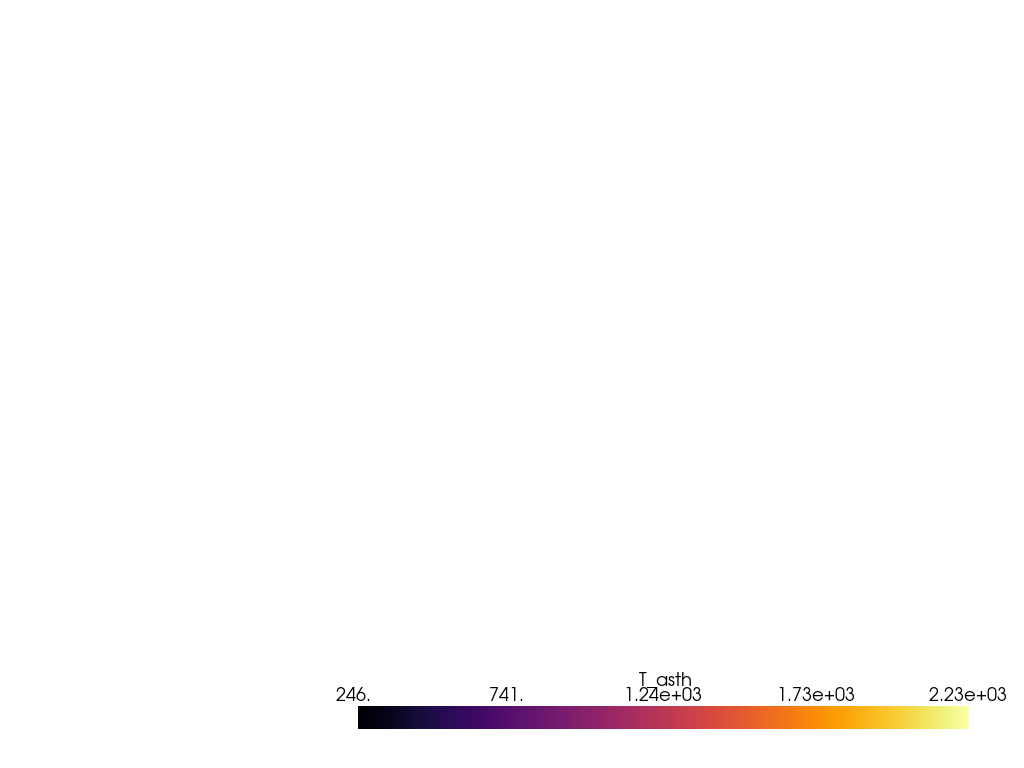

In [34]:
import pyvista as pvs

plotter = pvs.Plotter()
plotter.add_mesh(surface_mesh, scalars="T_asth", cmap="inferno", show_edges=False)
plotter.show()